# Visibility Graph on a Globe

Spherical visibility graph construction for great-circle air routing around restricted regions.

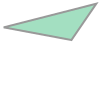

In [4]:
from shapely.geometry import Polygon

# Vertices as (lon, lat), matching GeoJSON axis order
CITIES = {
    "Bishkek": (74.59, 42.87),
    "Novosibirsk": (82.92, 55.03),
    "Atyrau": (51.92, 47.11),
}

obstacle = Polygon(CITIES.values())
obstacle

In [5]:
import pandas as pd

airports = pd.read_csv("data/airports.csv").set_index("ICAO")
route = airports.loc[["UAAA", "KJFK"], ["AirportName", "GeoPointLat", "GeoPointLong"]]
route

,AirportName,GeoPointLat,GeoPointLong
ICAO,,,
UAAA,Almaty,43.352072,77.040508
KJFK,John F Kennedy Intl,40.639751,-73.778925


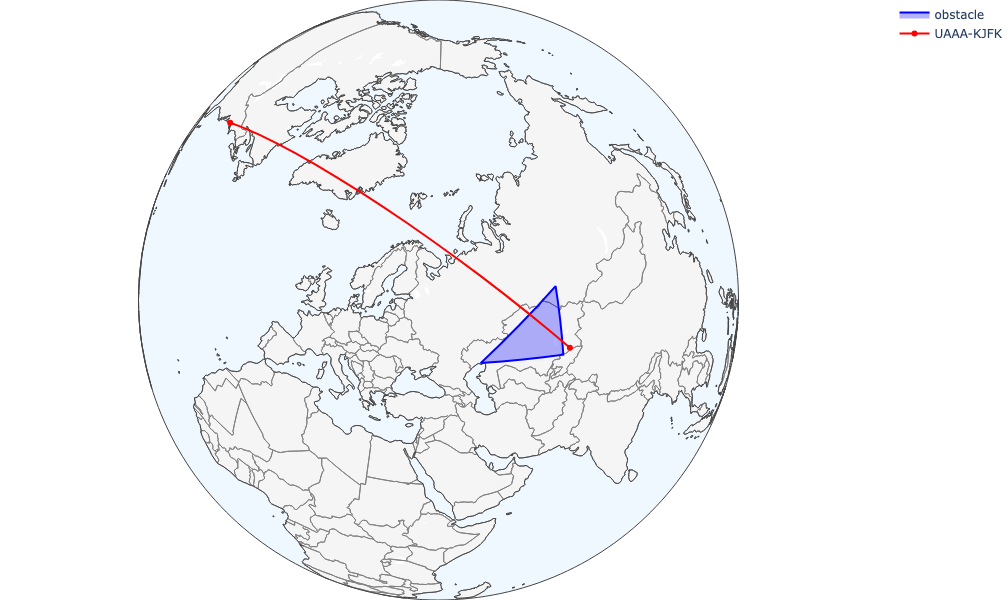

In [6]:
import plotly.graph_objects as go

# Clockwise winding: on a sphere d3 fills the region to the ring's left,
# so a counterclockwise ring paints everything except the triangle
ring = list(CITIES.values())[::-1]
lons, lats = zip(*ring)
lons = [*lons, lons[0]]  # close the ring
lats = [*lats, lats[0]]

fig = go.Figure(
    go.Scattergeo(
        lon=lons,
        lat=lats,
        mode="lines",
        line=dict(color="blue", width=2),
        fill="toself",
        fillcolor="rgba(0, 0, 255, 0.3)",
        name="obstacle",
    )
)
fig.add_trace(
    go.Scattergeo(
        lon=route["GeoPointLong"],
        lat=route["GeoPointLat"],
        mode="lines+markers",
        line=dict(color="red", width=2),
        marker=dict(color="red", size=6),
        name="UAAA-KJFK",
    )
)
fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lon=40, lat=60),
    showcountries=True,
    countrycolor="gray",
    showland=True,
    landcolor="whitesmoke",
    showocean=True,
    oceancolor="aliceblue",
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=0, b=0))
fig.show()

## Spherical visibility graph & GCD pathfinding

All geometry on the unit sphere: points are 3D unit vectors, edges are great-circle arcs, distances are central angles × Earth radius.

In [18]:
import numpy as np

R_EARTH = 6371.0088  # mean Earth radius, km

def to_unit(lon, lat):
    """(lon, lat) in degrees -> 3D unit vector."""
    lam, phi = np.radians(lon), np.radians(lat)
    return np.array([np.cos(phi) * np.cos(lam), np.cos(phi) * np.sin(lam), np.sin(phi)])

def to_lonlat(v):
    """3D unit vector -> (lon, lat) in degrees."""
    return np.degrees(np.arctan2(v[1], v[0])), np.degrees(np.arcsin(np.clip(v[2], -1, 1)))

def angle(u, v):
    """Central angle between unit vectors, stable near 0 and pi."""
    return np.arctan2(np.linalg.norm(np.cross(u, v)), np.dot(u, v))

def gcd_km(u, v):
    return angle(u, v) * R_EARTH

def slerp(u, v, n=100):
    """n points along the great-circle arc u -> v (inclusive)."""
    th = angle(u, v)
    t = np.linspace(0, 1, n)[:, None]
    return (np.sin((1 - t) * th) * u + np.sin(t * th) * v) / np.sin(th)

# smoke test: Almaty -> JFK should be ~10,300 km
print(f"{gcd_km(to_unit(77.0405, 43.3521), to_unit(-73.7789, 40.6398)):.1f} km")

10228.3 km


In [19]:
EPS = 1e-9

def strictly_inside_arc(x, a, b):
    """x lies on arc a->b, excluding the endpoints."""
    return (angle(a, x) + angle(x, b) <= angle(a, b) + EPS
            and angle(a, x) > EPS and angle(x, b) > EPS)

def arcs_cross(p1, p2, q1, q2):
    """True iff arcs p1->p2 and q1->q2 intersect strictly interior to both.
    Touching at a shared endpoint does not count as a crossing."""
    n1 = np.cross(p1, p2)
    n2 = np.cross(q1, q2)
    t = np.cross(n1, n2)
    nt = np.linalg.norm(t)
    if nt < EPS:  # same great circle: overlap iff any endpoint is strictly inside the other arc
        return any(strictly_inside_arc(x, a, b)
                   for x, a, b in ((q1, p1, p2), (q2, p1, p2), (p1, q1, q2), (p2, q1, q2)))
    t = t / nt
    return any(strictly_inside_arc(x, p1, p2) and strictly_inside_arc(x, q1, q2)
               for x in (t, -t))

def point_in_spherical_polygon(v, ring):
    """Winding-number test on the sphere: sum of signed angles subtended by the
    edges in the tangent plane at v is ~±2π inside, ~0 outside, ~±π on the boundary."""
    total = 0.0
    m = len(ring)
    for i in range(m):
        a, b = ring[i], ring[(i + 1) % m]
        ta = a - v * np.dot(v, a)  # project onto tangent plane at v
        tb = b - v * np.dot(v, b)
        total += np.arctan2(np.dot(np.cross(ta, tb), v), np.dot(ta, tb))
    return abs(total) > 1.5 * np.pi

def arc_visible(a, b, ring):
    """Arc a->b is unobstructed by the polygon: crosses no edge and its
    midpoint is not interior (catches chords between vertices of the same polygon)."""
    m = len(ring)
    if any(arcs_cross(a, b, ring[i], ring[(i + 1) % m]) for i in range(m)):
        return False
    mid = a + b
    mid = mid / np.linalg.norm(mid)
    return not point_in_spherical_polygon(mid, ring)

# smoke tests: equator/meridian arcs cross at (0,0); point at lon 70, lat 48 is inside the triangle
print(arcs_cross(to_unit(-10, 0), to_unit(10, 0), to_unit(0, -10), to_unit(0, 10)))
print(point_in_spherical_polygon(to_unit(70, 48), [to_unit(lon, lat) for lon, lat in CITIES.values()]))

True
True


In [20]:
import networkx as nx

nodes = {name: to_unit(lon, lat) for name, (lon, lat) in CITIES.items()}
for icao in ("UAAA", "KJFK"):
    nodes[icao] = to_unit(route.loc[icao, "GeoPointLong"], route.loc[icao, "GeoPointLat"])

ring_names = list(CITIES)
ring = [nodes[n] for n in ring_names]

for icao in ("UAAA", "KJFK"):
    assert not point_in_spherical_polygon(nodes[icao], ring), f"{icao} is inside the obstacle"

print("direct UAAA-KJFK blocked:", not arc_visible(nodes["UAAA"], nodes["KJFK"], ring))

G = nx.Graph()
m = len(ring_names)
for i in range(m):  # polygon boundary is always traversable
    u, v = ring_names[i], ring_names[(i + 1) % m]
    G.add_edge(u, v, weight=gcd_km(nodes[u], nodes[v]))

names = list(nodes)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        u, v = names[i], names[j]
        if not G.has_edge(u, v) and arc_visible(nodes[u], nodes[v], ring):
            G.add_edge(u, v, weight=gcd_km(nodes[u], nodes[v]))

print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
for u, v, d in sorted(G.edges(data=True), key=lambda e: e[2]["weight"]):
    print(f"{u:>11} - {v:<11} {d['weight']:8.1f} km")

direct UAAA-KJFK blocked: True
5 nodes, 7 edges
    Bishkek - UAAA           206.0 km
Novosibirsk - UAAA          1365.8 km
    Bishkek - Novosibirsk   1480.2 km
    Bishkek - Atyrau        1836.8 km
Novosibirsk - Atyrau        2314.3 km
     Atyrau - KJFK          8881.5 km
Novosibirsk - KJFK          9149.6 km


In [21]:
heuristic = lambda u, v: gcd_km(nodes[u], nodes[v])  # admissible: direct GCD never overestimates

path = nx.astar_path(G, "UAAA", "KJFK", heuristic=heuristic, weight="weight")
path_km = nx.path_weight(G, path, weight="weight")
direct_km = gcd_km(nodes["UAAA"], nodes["KJFK"])

print(" -> ".join(path))
print(f"constrained path: {path_km:8.1f} km")
print(f"unconstrained GCD:{direct_km:8.1f} km")
print(f"detour penalty:   {path_km - direct_km:+8.1f} km ({(path_km / direct_km - 1) * 100:.2f}%)")

# validation: densify each leg and assert it never enters the obstacle interior
for a, b in zip(path, path[1:]):
    for p in slerp(nodes[a], nodes[b], 200)[1:-1]:
        assert not point_in_spherical_polygon(p, ring), f"leg {a}->{b} enters the obstacle"
print("validation passed: no path leg enters the obstacle")

UAAA -> Novosibirsk -> KJFK
constrained path:  10515.4 km
unconstrained GCD: 10228.3 km
detour penalty:     +287.1 km (2.81%)
validation passed: no path leg enters the obstacle


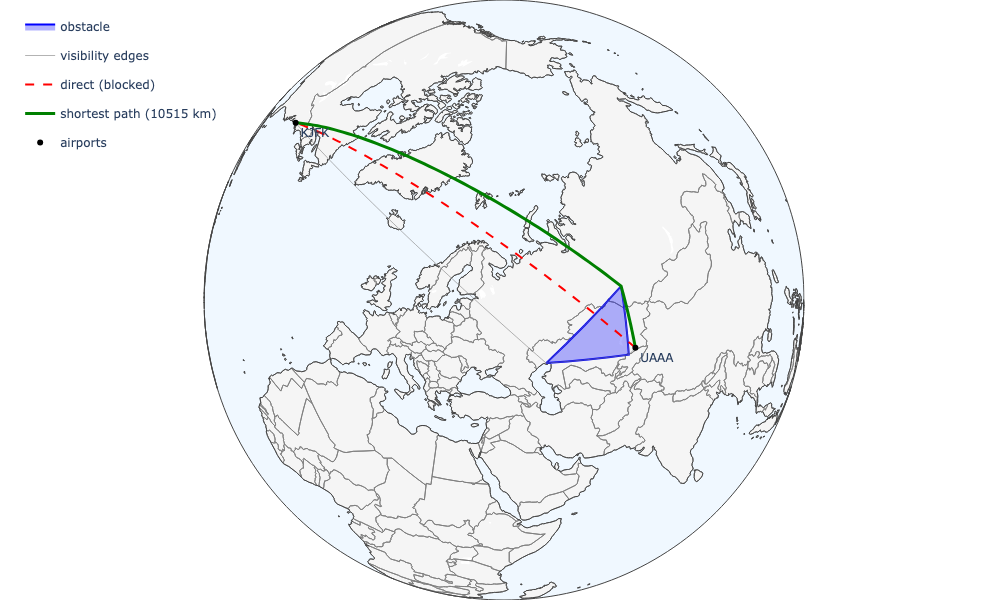

In [22]:
def arc_lonlat(a, b, n=64):
    pts = slerp(a, b, n)
    lons, lats = zip(*(to_lonlat(p) for p in pts))
    return list(lons), list(lats)

fig = go.Figure()

ring_cw = list(CITIES.values())[::-1]  # clockwise so d3 fills the inside
lons, lats = zip(*ring_cw)
fig.add_trace(go.Scattergeo(
    lon=[*lons, lons[0]], lat=[*lats, lats[0]], mode="lines",
    line=dict(color="blue", width=2), fill="toself",
    fillcolor="rgba(0, 0, 255, 0.3)", name="obstacle"))

path_legs = set(zip(path, path[1:])) | set(zip(path[1:], path))
first = True
for u, v in G.edges():
    if (u, v) in path_legs:
        continue
    lo, la = arc_lonlat(nodes[u], nodes[v])
    fig.add_trace(go.Scattergeo(
        lon=lo, lat=la, mode="lines", line=dict(color="gray", width=1),
        opacity=0.6, name="visibility edges", legendgroup="vis", showlegend=first))
    first = False

lo, la = arc_lonlat(nodes["UAAA"], nodes["KJFK"])
fig.add_trace(go.Scattergeo(
    lon=lo, lat=la, mode="lines",
    line=dict(color="red", width=2, dash="dash"), name="direct (blocked)"))

path_lons, path_lats = [], []
for a, b in zip(path, path[1:]):
    lo, la = arc_lonlat(nodes[a], nodes[b])
    path_lons += lo
    path_lats += la
fig.add_trace(go.Scattergeo(
    lon=path_lons, lat=path_lats, mode="lines",
    line=dict(color="green", width=3), name=f"shortest path ({path_km:.0f} km)"))

fig.add_trace(go.Scattergeo(
    lon=[route.loc[i, "GeoPointLong"] for i in ("UAAA", "KJFK")],
    lat=[route.loc[i, "GeoPointLat"] for i in ("UAAA", "KJFK")],
    mode="markers+text", text=["UAAA", "KJFK"], textposition="bottom right",
    marker=dict(color="black", size=6), name="airports"))

fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lon=40, lat=60),
    showcountries=True, countrycolor="gray",
    showland=True, landcolor="whitesmoke",
    showocean=True, oceancolor="aliceblue")
fig.update_layout(height=600, margin=dict(l=0, r=0, t=0, b=0),
                  legend=dict(x=0.02, y=0.98, bgcolor="rgba(255,255,255,0.7)"))
fig.show()